In [ ]:
# transferable code functions
import numpy as np
import scipy.signal as scisig
from omegaconf import DictConfig, OmegaConf
from http.server import BaseHTTPRequestHandler, HTTPServer
from functools import partial
import json

trn_cfg = OmegaConf.load("hyper_params.yaml")

def padding(layer:np.ndarray, mode:str = 'zero', pad_size:int = 1):

    for i in range(pad_size):

        padded_ly_size = (layer.shape[0]+2, layer.shape[1]+2)
        padded_ly = np.zeros(padded_ly_size)
        padded_ly[1:-1,1:-1] = layer
    
        if mode == 'same':
            padded_ly[0,1:-1] = layer[0,:]
            padded_ly[-1,1:-1] = layer[-1,:]

            padded_ly[1:-1,0] = layer[:,0]
            padded_ly[1:-1,-1] = layer[:,-1]

            padded_ly[0,0] = layer[0,0]
            padded_ly[0,-1] = layer[0,-1]
            padded_ly[-1,0] = layer[-1,0]
            padded_ly[-1,-1] = layer[-1,-1]
        layer = padded_ly

    return(padded_ly)

def convolve(input:np.ndarray, kernel:np.ndarray, pad_mode:str = 'zero', pad_size:int = 666, conv_mode:str="valid"):
    if pad_mode !="none":
        if pad_size == 666:
            pad_size = kernel.shape[0]//2
        input = padding(input, pad_mode, pad_size)
    k_shp = kernel.shape
    #print(input.shape)
    result = scisig.convolve(input, kernel, mode=conv_mode, method="fft")

    return(result)

def patch_convolve(input:np.ndarray, patch_shape:tuple, error_array:np.ndarray, pad_mode:str = 'zero', pad_size:int = 666, conv_mode:str="valid"):
    if pad_mode !="none":
        if pad_size == 666:
            pad_size = patch_shape[0]//2
        input = padding(input, pad_mode, pad_size)
    
    error_patch_arr = np.zeros(shape=(*error_array.shape, *patch_shape))

    for i in range(error_array.shape[0]):
        for j in range(error_array.shape[1]):
            error_patch_arr[i,j,:,:] = input[i:i+patch_shape[0], j:j+patch_shape[1]] * error_array[i,j]
    kernel_delta = np.sum(error_patch_arr, axis=(0,1))
    return(kernel_delta)

def fast_patch_convolve(input:np.ndarray, patch_shape:tuple, error_array:np.ndarray, 
                        pad_mode:str = 'zero', pad_size:int = 666, conv_mode:str="valid"):
    from numpy.lib.stride_tricks import sliding_window_view
    if pad_mode !="none":
        if pad_size == 666:
            pad_size = patch_shape[0]//2
        input = padding(input, pad_mode, pad_size)

    patches = sliding_window_view(input, patch_shape)
    op1 = patches * error_array[:,:, np.newaxis, np.newaxis] #Need to understand this better

    dW = np.sum(op1, axis=(0,1))
    #dw is the delta in the filter/kernel/patch
    return(dW)

def pool(input:np.ndarray, stride = 2, mode = "max"):
    out_h, out_w = input.shape[0]//stride, input.shape[1]//stride
    source_mask = np.zeros_like(input)

    # group each stride x stride region into the last axis: shape (out_h, out_w, stride*stride)
    trimmed = input[:out_h*stride, :out_w*stride]
    regions = trimmed.reshape(out_h, stride, out_w, stride).transpose(0, 2, 1, 3).reshape(out_h, out_w, stride*stride)

    if mode =="max":
        max_idx = np.argmax(regions, axis=-1)
        output = np.take_along_axis(regions, max_idx[..., np.newaxis], axis=-1)[..., 0]
        # only the first max in each region gets the gradient, so ties (common on the flat black
        # background of MNIST) don't copy the gradient into every tied cell
        local_mask = (np.arange(stride*stride) == max_idx[..., np.newaxis]).astype(input.dtype)
    elif mode =="mean":
        output = np.mean(regions, axis=-1)
        local_mask = np.ones_like(regions)
    else:
        raise ValueError(f"Unsupported pooling mode: {mode}")

    source_mask[:out_h*stride, :out_w*stride] = local_mask.reshape(out_h, out_w, stride, stride).transpose(0, 2, 1, 3).reshape(out_h*stride, out_w*stride)
    return(source_mask, output)

def sigmond(input):
    return( 1/(1+np.exp(-input)))

def sigmond_prime(input):
    return(sigmond(input) * (1-sigmond(input)))

def ReLU(input):
    return(np.maximum(0, input))

def ReLU_prime(input):
    return(input > 0).astype(input.dtype)

def LeakyReLU(input, alpha = 0.01):
    return np.where(input > 0, input, alpha * input)

def LeakyReLU_prime(input, alpha = 0.01):
    return np.where(input > 0, 1, alpha)

def deep_copy_mat_list (list_to_copy, propigate_cell_vals=True):
    #creates a copy of a list containing numpy arrays of varible size, ethier as empty arrays or with the same values
    
    new_list = []
    if propigate_cell_vals:
        for items in list_to_copy:
            new_list.append(items)
    else:
        for items in list_to_copy:
            new_list.append(np.zeros_like(items))       

    return(new_list)

def label_to_output(int) -> np.ndarray:
    outlayer = np.zeros(shape=(10), dtype=np.float32)
    outlayer[int] = 1
    return(outlayer)

def label_vec_to_output(inputs: np.ndarray) -> np.ndarray:
    # Create an identity matrix of size 10 and index into 
    return np.eye(10, dtype=np.int8)[inputs]


MNIST_MEAN = 0.1307
MNIST_STD = 0.3081

def load_mnist(images_path, labels_path):
    """
    Given an MNIST idx image file and label file, loads the whole set into memory and returns:

    images: an ndarray of shape (num_images, height, width) of type float32, scaled from 0-255 down to 0-1
    and then normalized with the MNIST mean and std so the values are roughly centered on 0

    labels: an ndarray of shape (num_images,) of type int64
    """
    with open(images_path, 'rb') as f:
        header = np.frombuffer(f.read(16), dtype='>u4')
        num_images, rows, cols = int(header[1]), int(header[2]), int(header[3])
        images = np.frombuffer(f.read(), dtype=np.uint8).astype(np.float32)
    images = np.reshape(images, (num_images, rows, cols))
    images = (images / 255.0 - MNIST_MEAN) / MNIST_STD

    with open(labels_path, 'rb') as l:
        l.read(8)
        labels = np.frombuffer(l.read(), dtype=np.uint8).astype(np.int64)

    return(images, labels)

def loss(network_output_ly, expected_ly):
    #loss =  mean of all output neurons - the expected, squared
    loss_vec = ((network_output_ly - expected_ly)**2) / 2
    loss_sclr = np.sum((network_output_ly - expected_ly)**2)
    return(loss_sclr, loss_vec)

def clip_grad(grad:np.ndarray, max_normal_val =  10.0):
    norm = np.linalg.norm(grad) 
    if norm > max_normal_val:
        return grad * (max_normal_val / norm)
    else:
        return grad
    
def clip_activations(activations:np.ndarray, z_vals:np.ndarray, threshold = 50):
    warnings = []
    if np.max(np.abs(activations)) > threshold:
        warnings.append("activation high value detected")
        activations = np.clip(activations, -threshold, threshold)
    if np.isnan(activations).any():
        warnings.append("activation NaN detected")
    z_val_threshold = 100
    if np.max(np.abs(z_vals)) > z_val_threshold:
        warnings.append("z_vals high value detected")
        z_vals = np.clip(z_vals, -z_val_threshold, z_val_threshold)
    if np.isnan(z_vals).any():
        warnings.append("z value NaN detected")
    return activations, z_vals, warnings

def softmax(input):
    exp_selected = np.exp(input - np.max(input, axis=-1, keepdims=True))
    return exp_selected / np.sum(exp_selected, axis=-1, keepdims=True)

def softmax_prime(input):
    s = softmax(input)
    return s * (1 - s)

def cross_entropy_loss(predictions, targets):
    """
    Cross-entropy loss for classification
    predictions: softmax output (probabilities)
    targets: one-hot encoded labels
    """
    # Clip to prevent log(0)
    predictions = np.clip(predictions, 1e-15, 1 - 1e-15)
    
    # Cross-entropy loss
    loss_vec = -targets * np.log(predictions)
    loss_scalar = np.sum(loss_vec)
    
    return loss_scalar, loss_vec

def cross_entropy_gradient(predictions, targets):
    """
    Gradient of cross-entropy loss with respect to pre-softmax logits
    This is the simplified gradient: predictions - targets
    """
    return predictions - targets

In [ ]:
from omegaconf import DictConfig, OmegaConf
mdl_cfg = OmegaConf.load("model.yaml")
import numpy as np
from dataclasses import dataclass
from omegaconf import DictConfig
import scipy.signal as scisig
import logging
import threading
import server
import datetime

logging.basicConfig(level=logging.ERROR)

def build_index_lookup(cfg: DictConfig):
    """
    Given a loaded OmegaConf config with a 'layers' section,
    build a lookup table: index -> (layer_name, layer_data).
    """
    blocks = cfg.blocks

    index_lookup = {
        block_data.index: (block_name, block_data)
        for block_name, block_data in blocks.items()
    }
    return index_lookup

class Input_block:
    def __init__(self, layer_shape, index, **kwargs): 
        #need to figure out how to properly use kwargs
        self.layer_shape = layer_shape
        self.index = index

        self.b_type = "input"
        self.ly_dim = len(layer_shape)
        self.activations = np.zeros(layer_shape, dtype=np.float32)
        self.z_values = np.zeros(layer_shape, dtype=np.float32)

    def backprop(self, expected:np.ndarray=None):
        return(0)

class FC_block:
    def __init__(self, prev_ly_shape, layer_shape, index, is_output = False, **kwargs): 
        #need to figure out how to properly use kwargs
        self.layer_shape = layer_shape
        self.index = index
        self.prev_ly_shape = prev_ly_shape

        self.b_type = "fc"
        self.alpha = 0.01 #leaky ReLU slope, overwritten from the hyper params in train()
        self.is_output = is_output
        self.ly_dim = len(layer_shape)
        self.input_size = np.prod(prev_ly_shape)
        self.output_size = np.prod(layer_shape)

        self.activations = np.zeros(layer_shape, dtype=np.float32)
        self.z_values = np.zeros(layer_shape, dtype=np.float32)
        self.biases = np.zeros(layer_shape, dtype=np.float32)

        self.weights = self._init_weights()
        self.W_delta = np.zeros_like(self.weights, dtype=np.float32)        
        self.B_delta = np.zeros_like(self.biases, dtype=np.float32)

    def _init_weights(self, init=True):
        fan_in = self.input_size
        if init:
            weights = np.random.randn(self.input_size, self.output_size) * np.sqrt(2.0 / fan_in)
        else:
            weights = np.zeros(shape=(self.input_size, self.output_size), dtype=np.float32)
        return(weights)
    
    def forward(self, input):
        self.z_values = np.zeros(self.layer_shape, dtype=np.float32)
        self.activations = np.zeros(self.layer_shape, dtype=np.float32)

        flattened_input = input.flatten()
        flattened_z = np.dot(flattened_input, self.weights) + self.biases.flatten()
        self.z_values = flattened_z.reshape(self.layer_shape)

        if self.is_output:
            self.activations = softmax(self.z_values)

        else:
            self.activations = LeakyReLU(self.z_values, self.alpha)

        self.activations, self.z_values, clip_warns = clip_activations(self.activations, self.z_values)
        if clip_warns:
            logging.warning(f"activations clip warning: {clip_warns} at layer {self.index}")

    def backprop(self, prior_activations:np.ndarray=None, prior_z_vals:np.ndarray=None, del_l:np.ndarray=None, expected:np.ndarray=None):
        self.W_delta = np.zeros_like(self.weights, dtype=np.float32)        
        self.B_delta = np.zeros_like(self.biases, dtype=np.float32)
        
        if self.is_output and expected is not None:
            #del_l = (expected - self.activations) * LeakyReLU_prime(self.z_values)
            #del_l = (self.activations - expected) * LeakyReLU_prime(self.z_values) #Claude suggested fixes
            del_l = self.activations - expected #Claude further suggested fixes.
            #print(self.activations)
            #print(expected)
        else:
            #del_l coming in is the error on this layer's activations, chain it through the activation function
            del_l = del_l * LeakyReLU_prime(self.z_values, self.alpha)

        del_l_flatted = del_l.flatten()
        flattened_input = prior_activations.flatten()

        #old slower code that presveres dimensions
        #if len(self.prev_ly_shape) == 1:
        #    del_l_neg1 = np.tensordot(self.weights, del_l, axes=((1),(0)))# * prior_z_vals
        #if len(self.prev_ly_shape) == 2:
        #    del_l_neg1 = np.tensordot(self.weights, del_l, axes=((2),(0)))# * prior_z_vals
        #self.W_delta = np.tensordot(prior_activations, del_l, axes=0)

        self.W_delta = np.outer(flattened_input, del_l_flatted)
        assert self.W_delta.shape == self.weights.shape
        self.B_delta = del_l

        flattened_del_neg1 = np.dot(self.weights, del_l_flatted)
        del_l_neg1 = flattened_del_neg1.reshape(self.prev_ly_shape)


        return(del_l_neg1, self.W_delta, self.B_delta)

class FC_CONV_block:
    def __init__(self, prev_bk_shape, layer_shape, index, is_output = False, **kwargs): 
        #need to figure out how to properly use kwargs
        self.layer_shape = layer_shape
        self.index = index
        self.prev_bk_shape = prev_bk_shape

        self.b_type = "fc_conv"
        self.alpha = 0.01 #leaky ReLU slope, overwritten from the hyper params in train()
        self.is_output = is_output
        self.ly_dim = len(layer_shape)
        self.input_size = np.prod(prev_bk_shape)
        self.output_size = np.prod(layer_shape)

        self.activations = np.zeros(layer_shape, dtype=np.float32)
        self.z_values = np.zeros(layer_shape, dtype=np.float32)
        self.biases = np.zeros(layer_shape, dtype=np.float32)
        self.weights = self._init_weights()

        self.B_delta = np.zeros_like(self.biases, dtype=np.float32)
        self.W_delta = np.zeros_like(self.weights, dtype=np.float32)

    def _init_weights(self, init=True):
        fan_in = self.input_size
        if init:
            weights = np.random.randn(self.input_size, self.output_size) * np.sqrt(2.0 / fan_in)
        else:
            weights = np.zeros(shape=(self.input_size, self.output_size), dtype=np.float32)
        return(weights)
    
    def forward(self, input):
        self.z_values = np.zeros(self.layer_shape)
        self.activations = np.zeros(self.layer_shape)

        flattened_input = input.flatten()
        flattened_z = np.dot(flattened_input, self.weights) + self.biases.flatten()
        self.z_values = flattened_z.reshape(self.layer_shape)
        if self.is_output:
            self.activations = softmax(self.z_values)

        else:
            self.activations = LeakyReLU(self.z_values, self.alpha)


        self.activations, self.z_values, clip_warns = clip_activations(self.activations, self.z_values)
        if clip_warns:
            logging.warning(f"activations clip warning: {clip_warns} at layer {self.index}")

    def backprop(self, prior_activations:np.ndarray=None, prior_z_vals:np.ndarray=None, del_l:np.ndarray=None, expected:np.ndarray=None):
        self.W_delta = np.zeros_like(self.weights)
        self.B_delta = np.zeros_like(self.biases)
        
        if self.is_output and expected is not None:
            #del_l = (expected - self.activations) * LeakyReLU_prime(self.z_values)
            #del_l = (self.activations - expected) * LeakyReLU_prime(self.z_values) #Claude suggested fixes
            del_l = self.activations - expected #Claude further suggested fixes.  I'm beginning to think Claude is full of shit.
        else:
            #del_l coming in is the error on this layer's activations, chain it through the activation function
            del_l = del_l * LeakyReLU_prime(self.z_values, self.alpha)
        
        #old slower code that presveres dimensions
        #if len(self.layer_shape) == 2:
        #    del_l_neg1 = np.tensordot(self.weights, del_l, axes=((3,4),(0,1)))# * prior_z_vals
        #if len(self.layer_shape) == 1:
        #    del_l_neg1 = np.tensordot(self.weights, del_l, axes=((3),(0)))# * prior_z_vals
        #self.W_delta = np.tensordot(prior_activations, del_l, axes=0)
        #self.B_delta = del_l


        del_l_flatted = del_l.flatten()
        flattened_input = prior_activations.flatten()

        self.W_delta = np.outer(flattened_input, del_l_flatted)
        assert self.W_delta.shape == self.weights.shape
        self.B_delta = del_l

        flattened_del_neg1 = np.dot(self.weights, del_l_flatted)
        del_l_neg1 = flattened_del_neg1.reshape(self.prev_bk_shape)

        return(del_l_neg1, self.W_delta, self.B_delta)

class Conv_Block:
    def __init__(self, prev_bk_depth, num_filters, kernel_shape, stride, layer_shape, index):
        self.num_filters = num_filters
        self.kernel_shape = kernel_shape
        self.stride = stride
        self.layer_shape = layer_shape
        self.index = index
        self.prev_bk_depth = prev_bk_depth


        self.b_type = "conv"
        self.alpha = 0.01 #leaky ReLU slope, overwritten from the hyper params in train()
        self.ly_dim = len(layer_shape)
        self.filters = self._init_filters(self.prev_bk_depth, self.num_filters, self.kernel_shape, init = True) #are of size (h,m,3,3) 
        self.z_values = np.zeros(shape=(self.num_filters, *self.layer_shape), dtype=np.float32)
        self.biases = np.zeros(shape=(self.num_filters,), dtype=np.float32) 
        self.activations = np.zeros_like(self.z_values, dtype=np.float32)
        self.W_delta = np.zeros_like(self.filters, dtype=np.float32)        
        self.B_delta = np.zeros_like(self.biases, dtype=np.float32)#not sure about this

    def _init_filters(self, prior_num_filters:int, num_filters:int, kernel_shape:tuple, init=True):
        if init:
            fan_in = self.prev_bk_depth * kernel_shape[0] * kernel_shape[1]
            filters = np.random.randn(prior_num_filters, num_filters, *kernel_shape) * np.sqrt(2/fan_in)
        else:
            filters = np.zeros((prior_num_filters, num_filters, *kernel_shape), dtype=np.float32)
        return (filters)

    #todo rename all these methods as internal methods
    def forward(self, input:np.ndarray):
        self.z_values = np.zeros(shape=(self.num_filters, *self.layer_shape), dtype=np.float32)       
        self.activations = np.zeros(shape=(self.num_filters, *self.layer_shape), dtype=np.float32)

        if len(input.shape) == 2:
            input = np.expand_dims(input, axis=0)
        pad = self.kernel_shape[0]//2
        for h in range(self.filters.shape[0]):
            padded_input = padding(input[h,:,:], 'zero', pad)
            for m in range(self.filters.shape[1]):
                #cross-correlation (no kernel flip), the standard CNN convention. backprop matches this.
                self.z_values[m,:,:] += scisig.correlate2d(padded_input, self.filters[h,m,:,:], mode="valid")
        self.z_values += self.biases[:, np.newaxis, np.newaxis]
        self.activations = LeakyReLU(self.z_values, self.alpha)

        self.activations, self.z_values, clip_warns = clip_activations(self.activations, self.z_values)
        if clip_warns:
            logging.warning(f"activations clip warning: {clip_warns} at layer {self.index}")

    def backprop(self, prior_activations:np.ndarray=None,
                 prior_z_vals:np.ndarray=None, del_l:np.ndarray=None, expected:np.ndarray=None):
        self.W_delta = np.zeros_like(self.filters, dtype=np.float32)
        self.B_delta = np.zeros_like(self.biases, dtype=np.float32)

        if len(prior_activations.shape) == 2:
            prior_activations = np.expand_dims(prior_activations, axis=0)

        #del_l coming in is the error on this layer's activations, chain it through the activation function
        delta = del_l * LeakyReLU_prime(self.z_values, self.alpha)
        self.B_delta = np.sum(delta, axis=(1, 2))

        pad = self.kernel_shape[0]//2
        height, width = prior_activations.shape[1], prior_activations.shape[2]
        neg1_error = np.zeros_like(prior_activations, dtype=np.float32)

        for h in range(self.filters.shape[0]):
            padded_input = padding(prior_activations[h,:,:], 'zero', pad)
            for m in range(self.filters.shape[1]):
                #filter gradient: slide the error map over the padded input, gives a kernel sized result
                self.W_delta[h,m,:,:] = scisig.correlate2d(padded_input, delta[m,:,:], mode="valid")
                #error for the previous layer: full convolution with the kernel, then trim off the padding
                back = scisig.convolve2d(delta[m,:,:], self.filters[h,m,:,:], mode="full")
                neg1_error[h] += back[pad:pad+height, pad:pad+width]

        #this is the error on the previous block's activations, that block applies its own activation derivative
        return(neg1_error, self.W_delta, self.B_delta)

class Pooling_ly:
    def __init__(self, shape, prev_3D_shape, num_filters, index, stride:int=2, p_type:str="max"):
        self.index = index
        self.shape = shape
        self.depth = num_filters
        self.stride = stride
        self.p_type = p_type
        self.b_type = "pooling"

        self.prev_3D_shape = prev_3D_shape
        self.activations = np.ndarray(shape=(self.depth, *self.shape), dtype=np.float32)
        self.z_values = np.zeros_like(self.activations, dtype=np.float32)
        self.source_mask = np.zeros(shape=(self.prev_3D_shape))
        #self.weights = np.ndarray(shape=(1,), dtype=np.float32)
        #self.biases = np.ndarray(shape=(1,), dtype=np.float32)


    def pooling(self, input_act):
        if len(input_act.shape) == 2:
            input_act = np.expand_dims(input_act, axis=0)
        
        self.activations = np.zeros((input_act.shape[0], *self.shape), dtype=np.float32)
        self.source_mask = np.zeros(shape=(self.prev_3D_shape), dtype=np.float32)
        for i in range(input_act.shape[0]):
            self.source_mask[i], self.activations[i,:,:] = pool(input_act[i,:,:], stride=self.stride, mode=self.p_type)
        

    def forward(self, input):
        self.pooling(input)
        self.z_values = self.activations

    def backprop(self, prior_activations:np.ndarray=None, prior_z_vals:np.ndarray=None, del_l:np.ndarray=None, expected:np.ndarray=None):
        if expected is not None:
            raise NotImplementedError("Expected values should not be passed to pooling layers.")
        s = self.stride
        del_l_neg1 = np.repeat(np.repeat(del_l, s, axis=1), s, axis=2) * self.source_mask #should be expanded over axes 1,2. axis 0 is the feature map dim
        if self.p_type == "mean":
            del_l_neg1 /= (self.stride ** 2) 
        self.W_delta = np.zeros_like(self.activations, dtype=np.float32)        
        self.B_delta = np.zeros_like(self.activations, dtype=np.float32)
        return(del_l_neg1, self.W_delta, self.B_delta)

#make some functions NN methods
#make indexing dynamic and done at network creation

class NN:
    def __init__(self, config:DictConfig, blocks: list):
        self.config = config
        self.blocks = blocks

    @classmethod
    def create_network(cls, cfg:DictConfig, **kwargs):
        index_to_block = build_index_lookup(cfg)
        logging.info("creating network....")

        blocks = []
        for items in cfg.blocks:
            #print(items)
            block_name, block_data = index_to_block[cfg.blocks[items].index]
            

            if block_data.type == "input":
                blocks.append(Input_block(block_data.shape, block_data.index))
            if block_data.type == "fc":
                if block_data.flags and block_data.flags.get("output", False):
                    if prev_bk_data.type == "conv2D":
                        prev_bk_shp = (prev_bk_data.filters.filter_num, *prev_bk_data.shape)
                        blocks.append(FC_CONV_block(prev_bk_shp, block_data.shape, block_data.index, is_output=True))
                    else:
                        blocks.append(FC_block(prev_bk_data.shape, block_data.shape, block_data.index, is_output=True))
                else:
                    if prev_bk_data.type == "conv2D":
                        prev_bk_shp = (prev_bk_data.filters.filter_num, *prev_bk_data.shape)
                        blocks.append(FC_CONV_block(prev_bk_shp, block_data.shape, block_data.index, is_output=False))
                    else:
                        blocks.append(FC_block(prev_bk_data.shape, block_data.shape, block_data.index, is_output=False))

            if block_data.type == "pool":
                prev_bk_shp = (prev_bk_data.filters.filter_num, *prev_bk_data.shape)
                blocks.append(Pooling_ly(block_data.shape, prev_bk_shp, prev_bk_data.filters.filter_num, block_data.index, block_data.stride, block_data.mode))

            if block_data.type == "conv2D":
                fltr = block_data.filters
                if prev_bk_data.type == "conv2D":
                    prev_bk_dpth = prev_bk_data.filters.filter_num
                elif prev_bk_data.type == "pool":
                    prev_bk_dpth = blocks[-1].depth
                else:
                    prev_bk_dpth = 1

                blocks.append(Conv_Block(prev_bk_dpth, fltr.filter_num, fltr.kernel_shape, fltr.stride, block_data.shape, block_data.index))

            prev_bk_name = block_name
            prev_bk_data = block_data

        logging.info("Done!")
        return cls(cfg, blocks)
    
    def forward(self, input_ly):
        self.blocks[0].activations = input_ly
        self.blocks[0].z_values = input_ly
        for index in range(len(self.blocks)):
            #print("\nindex: ", index)
            if index == 0:
                self.blocks[0].activations = input_ly
            else:
                self.blocks[index].forward(self.blocks[index-1].activations)
            #print(f"Block {index} activation max: {np.max(self.blocks[index].activations)}")
            #print(f"Block {index} activation min: {np.min(self.blocks[index].activations)}")

    def backprop(self, expected):
        #print("running backprop....")
        dW = []
        dB = []
        for index in range(len(self.blocks)-1, 0 , -1):


            #print("index: ", index)
            if index == len(self.blocks)-1:
                delL_back1, dW_tmp, dB_tmp = self.blocks[index].backprop(prior_activations = self.blocks[index-1].activations, 
                                                         prior_z_vals= self.blocks[index-1].z_values,
                                                         expected = expected
                                                         )
            else:
                delL_back1, dW_tmp, dB_tmp = self.blocks[index].backprop(prior_activations = self.blocks[index-1].activations, 
                                                         prior_z_vals= self.blocks[index-1].z_values,
                                                         del_l = delL_back1
                                                         )
            if self.blocks[index].b_type =="pooling":
                pass
            else:
                dW.append(dW_tmp)
                dB.append(dB_tmp)
        dW.reverse()
        dB.reverse()#doing this because they were created from back to front
        #print("Done!")
        return(dW, dB)

def batch_backprop(input_batch:np.ndarray, desired_output_batch:np.ndarray,
                    trn_cfg:DictConfig, mdl_cfg:DictConfig, n_net:NN):
    batch_dW = []
    batch_dB = []
    batch_loss = np.ndarray((trn_cfg.batch_size,), dtype=np.float32)

    for blocks in n_net.blocks:
        if blocks.b_type == "input":
            pass
        elif blocks.b_type == "pooling":
            pass
        else:
            if blocks.b_type == "conv":
                weights_shape = blocks.filters.shape
            else:
                weights_shape = blocks.weights.shape
            bias_shape = blocks.biases.shape

            batch_dW.append(np.zeros( shape=(trn_cfg.batch_size, *weights_shape), dtype=np.float32))
            batch_dB.append(np.zeros( shape=(trn_cfg.batch_size, *bias_shape), dtype=np.float32))

    for single_sample in range(trn_cfg.batch_size):        
        n_net.forward(input_batch[single_sample])
        dW, dB = n_net.backprop(desired_output_batch[single_sample])
        
        sub_index = 0
        for index, blocks in enumerate(n_net.blocks):
            #print(index)
            #print(sub_index)
            if blocks.b_type == "input":
                pass
            elif blocks.b_type == "pooling":
                pass
            else:
                batch_dW[sub_index][single_sample] = dW[sub_index]
                batch_dB[sub_index][single_sample] = dB[sub_index]
                sub_index = sub_index+1


        #loss_sclr, loss_vec = loss(n_net.blocks[-1].activations, desired_output_batch[single_sample])
        loss_sclr, loss_vec = cross_entropy_loss(n_net.blocks[-1].activations, desired_output_batch[single_sample])
        
        batch_loss[single_sample] = loss_sclr

    mean_loss = np.mean(batch_loss)
    np.set_printoptions(precision=3, suppress=True)
    logging.info(f"batch loss: {mean_loss}")
    logging.debug(f"sample activations: {n_net.blocks[-1].activations} \ndesired activations{desired_output_batch[1]}")

    mean_dW = []
    mean_dB = []
    for blocks in n_net.blocks:
        if blocks.b_type == "input":
            pass
        elif blocks.b_type == "pooling":
            pass
        else:
            if blocks.b_type == "conv":
                weights_shape = blocks.filters.shape
            else:
                weights_shape = blocks.weights.shape
            bias_shape = blocks.biases.shape
            mean_dW.append(np.zeros(shape=(weights_shape), dtype=np.float32))
            mean_dB.append(np.zeros(shape=(bias_shape), dtype=np.float32))
        
    sub_index = 0
    for index, blocks in enumerate(n_net.blocks):
            #print(index)
            #print(sub_index)
            if blocks.b_type == "input":
                pass
            elif blocks.b_type == "pooling":
                pass
            else:
                mean_dW[sub_index] = np.mean(batch_dW[sub_index], axis=0) #learning rate is applied in train(), after clipping
                mean_dB[sub_index] = np.mean(batch_dB[sub_index], axis=0) #learning rate is applied in train(), after clipping
                sub_index = sub_index+1


    return(mean_dW, mean_dB, mean_loss)

def train(trn_cfg:DictConfig, mdl_cfg:DictConfig, model:NN, broadcast=True):
    """
    this is the core training loop that trains through epochs.  
    requires training_cfg(trn_cfg) containing hyperparameters and image and label paths,
    and model_cfg(mdl_cfg) containing model architecture.

    """
    import time
    import matplotlib.pyplot as plt
    timestamp = datetime.datetime.now().strftime("%m_%d_%Y_%H-%M-%S")

    grad_bk_num = 0
    #print("batch complete, updating model weights")
    for index, blocks in enumerate(model.blocks):
        #print(index)
        #print(sub_index)
        if blocks.b_type == "input":
            pass
        elif blocks.b_type == "pooling":
            pass
        else:
            grad_bk_num = grad_bk_num + 1
    for blocks in model.blocks:
        blocks.alpha = trn_cfg.leaky_ReLU_alpha

    sv_perf = save_performance(trn_cfg, mdl_cfg, grad_bk_num)
    sv_model_wb = save_model_weights(mdl_cfg, model)

    shared_dict = {
        'epoch': 0,
        'loss': 0.0,
        'log' : [],
        'warnings': [],
        'history' : [],
        "current_dW" : [1,1,1],
        "current_dB" : [],
        "current_act" : [],
        "dW_history_max" : [],
        "dW_history_mean" : [],
        "dW_history_min" : [],
        "dB_history_max" : [],
        "dB_history_mean" : [],
        "dB_history_min" : [],
        "act_history_max" : [],
        "act_history_mean" : [],
        "act_history_min" : [],
        }
    
    

    if broadcast:
        threading.Thread(target=server.start_dashboard_server, args=(shared_dict,), daemon=True).start()
        logging.info(f"server started at 127.0.0.1")

    x_data, y_data = [],[]
    from IPython.display import clear_output
    start = time.time()

    sv_perf.update_metadata(None, None, -1, timestamp)

    all_images, all_labels = load_mnist(trn_cfg.images_path, trn_cfg.labels_path)
    dataset_size = min(trn_cfg.dataset_size, len(all_images))
    num_batches = dataset_size // trn_cfg.batch_size

    for epochs in range(trn_cfg.epochs):
        logging.info(f"epoch {int(epochs)} out of {int(trn_cfg.epochs)}")
        shared_dict["log"].append(f"epoch {int(epochs)} out of {int(trn_cfg.epochs)}")
        order = np.random.permutation(dataset_size) #new random sample order every epoch
        epoch_losses = []
        for batches in range(num_batches):
            logging.debug(f"running batch: {batches}")
            batch_idx = order[batches*trn_cfg.batch_size:(batches+1)*trn_cfg.batch_size]
            images = all_images[batch_idx]
            labels = label_vec_to_output(all_labels[batch_idx])
            batch_dW, batch_dB, batch_loss = batch_backprop(images, labels, trn_cfg, mdl_cfg, model)
            epoch_losses.append(batch_loss)

            #for index, layers in enumerate(batch_dW):
            #    print("Block[",index, "] dW max: ",np.max(layers))
            #    print("Block[",index, "] dW min: ",np.min(layers))
            #    print("Block[",index, "] dW mean: ",np.mean(layers))  
            #for index, layers in enumerate(batch_dB):
            #    print("Block[",index, "] dB max: ",np.max(layers))
            #    print("Block[",index, "] dB min: ",np.min(layers))
            #    print("Block[",index, "] dB mean: ",np.mean(layers))     
            sub_index = 0
            #print("batch complete, updating model weights")
            for index, blocks in enumerate(model.blocks):
                #print(index)
                #print(sub_index)
                if blocks.b_type == "input":
                    pass
                elif blocks.b_type == "pooling":
                    pass
                else:
                    if blocks.b_type == "conv":
                        model.blocks[index].filters -= trn_cfg.learning_rate * clip_grad(batch_dW[sub_index])
                    else:
                        model.blocks[index].weights -= trn_cfg.learning_rate * clip_grad(batch_dW[sub_index])
                    model.blocks[index].biases -= trn_cfg.learning_rate * clip_grad(batch_dB[sub_index])
                    sub_index = sub_index + 1
        

        epoch_loss = np.mean(epoch_losses) #mean over every batch in the epoch, not just the last one
        logging.info(f"epoch {int(epochs)} mean loss: {epoch_loss:.4f}")

        sv_perf.update_data(model, batch_dW, batch_dB, epochs)
        sv_perf.update_metadata(epochs, epoch_loss)

        sv_perf.save_to_temp()
        sv_model_wb.update(model)
        sv_model_wb.save_to_temp()

        #monitoring
        shared_dict["current_dW"] = [round((np.max(batch_dW[3]).item()), 4) , 
                                    round((np.min(batch_dW[3]).item()), 4) , 
                                    round((np.mean(batch_dW[3]).item()), 4) ] 
        
        shared_dict["dW_history_max"].append(shared_dict["current_dW"][0])
        shared_dict["dW_history_min"].append(shared_dict["current_dW"][1])
        shared_dict["dW_history_mean"].append(shared_dict["current_dW"][2])

        shared_dict["dB_history_max"].append(round((np.max(batch_dB[3]).item()), 4))
        shared_dict["dB_history_min"].append(round((np.min(batch_dB[3]).item()), 4))
        shared_dict["dB_history_mean"].append(round((np.mean(batch_dB[3]).item()), 4))

        shared_dict["act_history_max"].append(round((np.max(model.blocks[3].activations).item()), 4))
        shared_dict["act_history_min"].append(round((np.min(model.blocks[3].activations).item()), 4))
        shared_dict["act_history_mean"].append(round((np.mean(model.blocks[3].activations).item()), 4))

        shared_dict['history'].append((round(epoch_loss, 4)).item())
        shared_dict['epoch'] = int(epochs)
        shared_dict['loss'] = round(epoch_loss, 4)
        shared_dict['log'].append(f"Epoch {int(epochs)}, loss {round(epoch_loss, 4).item()}")

        
        x_data.append(epochs)
        y_data.append(epoch_loss)
        #clear_output(wait=True)        # Clear previous plot
        #plt.figure(figsize=(10, 4))
        #plt.plot(x_data, y_data, 'bo-')
        #plt.title("Epoch vs Loss")
        #plt.xlabel("Epoch")
        #plt.ylabel("Loss at epoch end")
        #plt.grid(True)
        #for index in range(len(x_data)):
        #    plt.text(x_data[index], y_data[index], f"{y_data[index]:.2f}", size=8)
        #plt.show()
    end = time.time()
    run_time = int(end - start)
    sv_perf.update_metadata(None,None,run_time)
    sv_model_wb.update(model)

    return(model, sv_perf, sv_model_wb, (x_data, y_data))

#todo:
    #write backprop DONE!
        #now done with symbolic backprop creation, need to consider:
        #should there be a backprop function for each block/layer or a golbal
    #revaluate model architechure for practical ability to detect objects
    #make a visualizer
    #figure out what's causing NAN values
    #make more efficient

class save_performance():
    def __init__(self, trn_cfg:DictConfig, mdl_cfg:DictConfig, grad_bk_num):
        import datetime
        self.mdl_cfg = mdl_cfg
        self.trn_cfg = trn_cfg
        self.trn_cfg.runtime = -1
        self.trn_cfg.date = datetime.datetime.now().strftime("%m_%d_%Y_%H-%M-%S")

        
        self.save_dict_arrays = {
            "loss" : np.zeros(shape = ((trn_cfg.epochs),1)),
            "mean_dW_high" : np.zeros(shape = ((trn_cfg.epochs),1)),
            "mean_dW_mean" : np.zeros(shape = ((trn_cfg.epochs),1)),
            "mean_dW_low" : np.zeros(shape = ((trn_cfg.epochs),1)),
            "mean_dB_high" : np.zeros(shape = ((trn_cfg.epochs),1)),
            "mean_dB_mean" : np.zeros(shape = ((trn_cfg.epochs),1)),
            "mean_dB_low" : np.zeros(shape = ((trn_cfg.epochs),1)),        
            "mean_act_high" : np.zeros(shape = ((trn_cfg.epochs),1)),
            "mean_act_mean" : np.zeros(shape = ((trn_cfg.epochs),1)),
            "mean_act_low" : np.zeros(shape = ((trn_cfg.epochs),1)),
            "dW_highs" : np.zeros(shape = ((trn_cfg.epochs),grad_bk_num)),
            "dW_means" : np.zeros(shape = ((trn_cfg.epochs),grad_bk_num)),
            "dW_lows" : np.zeros(shape = ((trn_cfg.epochs),grad_bk_num)),
            "dB_highs" : np.zeros(shape = ((trn_cfg.epochs),grad_bk_num)),
            "dB_means" : np.zeros(shape = ((trn_cfg.epochs),grad_bk_num)),
            "dB_lows" : np.zeros(shape = ((trn_cfg.epochs),grad_bk_num)),        
            "W_highs" : np.zeros(shape = ((trn_cfg.epochs),grad_bk_num)),
            "W_means" : np.zeros(shape = ((trn_cfg.epochs),grad_bk_num)),
            "W_lows" : np.zeros(shape = ((trn_cfg.epochs),grad_bk_num)),
            "B_highs" : np.zeros(shape = ((trn_cfg.epochs),grad_bk_num)),
            "B_means" : np.zeros(shape = ((trn_cfg.epochs),grad_bk_num)),
            "B_lows" : np.zeros(shape = ((trn_cfg.epochs),grad_bk_num)), 
            "act_highs" : np.zeros(shape = ((trn_cfg.epochs),grad_bk_num)),
            "act_means" : np.zeros(shape = ((trn_cfg.epochs),grad_bk_num)),
            "act_lows" : np.zeros(shape = ((trn_cfg.epochs),grad_bk_num)),
        }

    def update_data(self, model:NN, batch_dW, batch_dB, epoch):
        
                # saving data
        sub_index = 0
        act_high_stats = []
        act_mean_stats = []
        act_low_stats = []
        dW_high_stats = []
        dW_mean_stats = []
        dW_low_stats = []
        dB_high_stats = []
        dB_mean_stats = []
        dB_low_stats = []
        for index, blocks in enumerate(model.blocks):

            if blocks.b_type == "input":
                pass
            elif blocks.b_type == "pooling":
                act_high_stats.append(np.max(model.blocks[index].activations))
                act_mean_stats.append(np.mean(model.blocks[index].activations))
                act_low_stats.append(np.min(model.blocks[index].activations))
                pass
            else:
                self.save_dict_arrays["act_highs"][epoch, sub_index] = (round((np.max(model.blocks[index].activations).item()), 4))
                self.save_dict_arrays["act_means"][epoch, sub_index] = (round((np.mean(model.blocks[index].activations).item()), 4))
                self.save_dict_arrays["act_lows"][epoch, sub_index] = (round((np.min(model.blocks[index].activations).item()), 4))

                self.save_dict_arrays["dW_highs"][epoch, sub_index] = (round((np.max(batch_dW[sub_index]).item()), 4))
                self.save_dict_arrays["dW_means"][epoch, sub_index] = (round((np.mean(batch_dW[sub_index]).item()), 4))
                self.save_dict_arrays["dW_lows"][epoch, sub_index] = (round((np.min(batch_dW[sub_index]).item()), 4))

                self.save_dict_arrays["dB_highs"][epoch, sub_index] = (round((np.max(batch_dB[sub_index]).item()), 4))
                self.save_dict_arrays["dB_means"][epoch, sub_index] = (round((np.mean(batch_dB[sub_index]).item()), 4))
                self.save_dict_arrays["dB_lows"][epoch, sub_index] = (round((np.min(batch_dB[sub_index]).item()), 4))

                if blocks.b_type == "conv":
                    self.save_dict_arrays["W_highs"][epoch, sub_index] = (round((np.max(model.blocks[index].filters).item()), 4))
                    self.save_dict_arrays["W_means"][epoch, sub_index] = (round((np.mean(model.blocks[index].filters).item()), 4))
                    self.save_dict_arrays["W_lows"][epoch, sub_index] = (round((np.min(model.blocks[index].filters).item()), 4))

                elif blocks.b_type in ["fc", "fc_conv"]:
                    self.save_dict_arrays["W_highs"][epoch, sub_index] = (round((np.max(model.blocks[index].weights).item()), 4))
                    self.save_dict_arrays["W_means"][epoch, sub_index] = (round((np.mean(model.blocks[index].weights).item()), 4))
                    self.save_dict_arrays["W_lows"][epoch, sub_index] = (round((np.min(model.blocks[index].weights).item()), 4))

                else:
                    raise IndexError("impossible index location: no appropreate block type for saving weights and biases")
                
                self.save_dict_arrays["B_highs"][epoch, sub_index] = (round((np.max(model.blocks[index].biases).item()), 4))
                self.save_dict_arrays["B_means"][epoch, sub_index] = (round((np.mean(model.blocks[index].biases).item()), 4))
                self.save_dict_arrays["B_lows"][epoch, sub_index] = (round((np.min(model.blocks[index].biases).item()), 4))
           
                act_high_stats.append(np.max(model.blocks[index].activations))
                act_mean_stats.append(np.mean(model.blocks[index].activations))
                act_low_stats.append(np.min(model.blocks[index].activations))

                dW_high_stats.append(np.max(batch_dW[sub_index]))
                dW_mean_stats.append(np.mean(batch_dW[sub_index]))
                dW_low_stats.append(np.min(batch_dW[sub_index]))
                
                dB_high_stats.append(np.max(batch_dB[sub_index]))
                dB_mean_stats.append(np.mean(batch_dB[sub_index]))
                dB_low_stats.append(np.min(batch_dB[sub_index]))

                sub_index = sub_index + 1

        self.save_dict_arrays["mean_act_high"][epoch] = round(np.mean(act_high_stats).item(), 4)
        self.save_dict_arrays["mean_act_mean"][epoch] = round(np.mean(act_mean_stats).item(), 4)
        self.save_dict_arrays["mean_act_low"][epoch] = round(np.mean(act_low_stats).item(), 4)

        self.save_dict_arrays["mean_dW_high"][epoch] = round(np.mean(dW_high_stats).item(), 4)
        self.save_dict_arrays["mean_dW_mean"][epoch] = round(np.mean(dW_mean_stats).item(), 4)
        self.save_dict_arrays["mean_dW_low"][epoch] = round(np.mean(dW_low_stats).item(), 4)

        self.save_dict_arrays["mean_dB_high"][epoch] = round(np.mean(dB_high_stats).item(), 4)
        self.save_dict_arrays["mean_dB_mean"][epoch] = round(np.mean(dB_mean_stats).item(), 4)
        self.save_dict_arrays["mean_dB_low"][epoch] = round(np.mean(dB_low_stats).item(), 4)

    def update_metadata(self, epoch = None, loss = None, run_time=None, date=None):
        """saves run data to conv_training/date.npz.  date should be a datetime type formatted as: "%m_%d_%Y_%H-%M-%S. 
        """

        if loss is not None and epoch is not None:
            self.save_dict_arrays["loss"][epoch] = loss
        if run_time is not None:
            self.trn_cfg.runtime = run_time
        if date:
            self.trn_cfg.date = date
    
    def save_to_file(self):
        import os
        if self.trn_cfg.date is None:
            self.trn_cfg.date = "not_today_satan"
            raise NotImplementedError("Attempting to save performance before execution")
        
        run_dir = f"conv_training/{self.trn_cfg.date}"
        os.makedirs(run_dir, exist_ok=True)  # `exist_ok=True` prevents error if dir exists
        OmegaConf.save(self.trn_cfg, f=f"{run_dir}/hyper_params.yaml")
        OmegaConf.save(self.mdl_cfg, f=f"{run_dir}/model.yaml")
        np.savez(f"{run_dir}/run_data.npz", **self.save_dict_arrays)

    def save_to_temp(self):
        """saves run data to conv_training/not_today_satan.npz.
        to be called during training in case of power loss or unexpected error      
        """
        import os        
        run_dir = f"conv_training/not_today_satan"
        os.makedirs(run_dir, exist_ok=True)  # `exist_ok=True` prevents error if dir exists
        OmegaConf.save(self.trn_cfg, f=f"{run_dir}/hyper_params.yaml")
        OmegaConf.save(self.mdl_cfg, f=f"{run_dir}/model.yaml")
        np.savez(f"{run_dir}/run_data.npz", **self.save_dict_arrays)

class save_model_weights():
    def __init__(self, mdl_cfg, model:NN):
        self.mdl_cfg = mdl_cfg
        self.path = None

        self.weights = []
        self.biases = []

        for index, blocks in enumerate(model.blocks):

            if blocks.b_type == "input":
                pass
            elif blocks.b_type == "pooling":
                pass
            else:
                if blocks.b_type == "conv":
                    self.weights.append(model.blocks[index].filters)
                else:
                    self.weights.append(model.blocks[index].weights)
                
                self.biases.append(model.blocks[index].biases)

    def save_to_file(self, run_date):
        """saves weigths and baises to conv_training/date.npz.  date should be a datetime type formatted as: "%m_%d_%Y_%H-%M-%S. 
        """
        import os
        if run_date is None:
            self.trn_cfg.date = "not_today_satan"
            raise NotImplementedError("Attempting to save performance before execution")
        
        run_dir = f"conv_training/{run_date}"
        os.makedirs(run_dir, exist_ok=True)  # `exist_ok=True` prevents error if dir exists
        OmegaConf.save(self.mdl_cfg, f=f"{run_dir}/model.yaml")
        np.savez(f"{run_dir}/weights.npz", **{f'arr_{i}': arr for i, arr in enumerate(self.weights)})
        np.savez(f"{run_dir}/biases.npz", **{f'arr_{i}': arr for i, arr in enumerate(self.biases)})

    def save_to_temp(self):
        """saves run data to conv_training/not_today_satan.npz.
        to be called during training in case of power loss or unexpected error      
        """
        import os       
        run_dir = f"conv_training/not_today_satan"
        os.makedirs(run_dir, exist_ok=True)  # `exist_ok=True` prevents error if dir exists
        OmegaConf.save(self.mdl_cfg, f=f"{run_dir}/model.yaml")
        np.savez(f"{run_dir}/weights.npz", **{f'arr_{i}': arr for i, arr in enumerate(self.weights)})
        np.savez(f"{run_dir}/biases.npz", **{f'arr_{i}': arr for i, arr in enumerate(self.biases)})

    def update(self, model):
        subdex = 0
        for index, blocks in enumerate(model.blocks):
            if blocks.b_type == "input":
                pass
            elif blocks.b_type == "pooling":
                pass
            else:

                if blocks.b_type == "conv":
                    self.weights[subdex] = (model.blocks[index].filters)
                else:
                    self.weights[subdex] = (model.blocks[index].weights)
                
                self.biases[subdex] = (model.blocks[index].biases)

                subdex += 1
        pass


In [ ]:
#gradient check: compares the gradients from backprop against numerical ones (finite differences).
#if backprop is correct the relative errors are tiny (float32 forward pass, so ~1e-3 or less is good).
#an error near 1.0 means that gradient is wrong.
def gradient_check(model:NN, image:np.ndarray, expected:np.ndarray, checks_per_layer:int = 8, eps:float = 1e-3):
    def sample_loss():
        model.forward(image)
        loss_sclr, loss_vec = cross_entropy_loss(model.blocks[-1].activations, expected)
        return(loss_sclr)

    model.forward(image)
    dW, dB = model.backprop(expected)

    sub_index = 0
    for blocks in model.blocks:
        if blocks.b_type == "input" or blocks.b_type == "pooling":
            continue
        params = blocks.filters if blocks.b_type == "conv" else blocks.weights
        for grads, values, name in ((dW[sub_index], params, "W"), (dB[sub_index], blocks.biases, "B")):
            rel_errors = []
            for i in range(checks_per_layer):
                idx = tuple(np.random.randint(s) for s in values.shape)
                original = values[idx]
                values[idx] = original + eps
                loss_plus = sample_loss()
                values[idx] = original - eps
                loss_minus = sample_loss()
                values[idx] = original

                numeric = (loss_plus - loss_minus) / (2*eps)
                analytic = grads[idx]
                rel_errors.append(abs(numeric - analytic) / max(abs(numeric) + abs(analytic), 1e-8))
            print(f"block {blocks.index} ({blocks.b_type}) {name}: median relative error {np.median(rel_errors):.2e}, worst {np.max(rel_errors):.2e}")
        sub_index = sub_index + 1

gc_cfg = OmegaConf.load("hyper_params.yaml")
gc_images, gc_labels = load_mnist(gc_cfg.images_path, gc_cfg.labels_path)
gc_model = NN.create_network(OmegaConf.load("model.yaml"))
gradient_check(gc_model, gc_images[0], label_vec_to_output(gc_labels[0]))


In [ ]:
mdl_cfg = OmegaConf.load("model.yaml")
lrn_cfg = OmegaConf.load("hyper_params.yaml")



model = NN.create_network(mdl_cfg)
trained_model, preformance, weights, loss_over_time_xy = train(lrn_cfg, mdl_cfg, model)

preformance.save_to_file()
weights.save_to_file(preformance.trn_cfg.date)


In [ ]:
import matplotlib.pyplot as plt

#evaluate on the 10k test images, which the network never trained on
test_images, test_labels = load_mnist("MNIST/t10k-images.idx3-ubyte", "MNIST/t10k-labels.idx1-ubyte")

choice = 20
plt.imshow(test_images[choice])
plt.show()
print("image key: ", test_labels[choice])

trained_model.forward(test_images[choice])
np.set_printoptions(precision=4, suppress=True)
print("network's guess: ", np.argmax(trained_model.blocks[-1].activations))
print(trained_model.blocks[-1].activations)

num_correct = 0
for choice in range(len(test_images)):
    trained_model.forward(test_images[choice])
    if np.argmax(trained_model.blocks[-1].activations) == test_labels[choice]:
        num_correct = num_correct + 1
print(f" num samples:{len(test_images)}, num correct:{num_correct}")
print(f"overall accuracy:{num_correct/len(test_images)}")


loss
mean_dW_high
mean_dW_mean
mean_dW_low
mean_dB_high
mean_dB_mean
mean_dB_low
mean_act_high
mean_act_mean
mean_act_low
dW_highs
dW_means
dW_lows
dB_highs
dB_means
dB_lows
W_highs
W_means
W_lows
B_highs
B_means
B_lows
act_highs
act_means
act_lows


Text(0.5, 0.98, 'CNN loss over epochs')

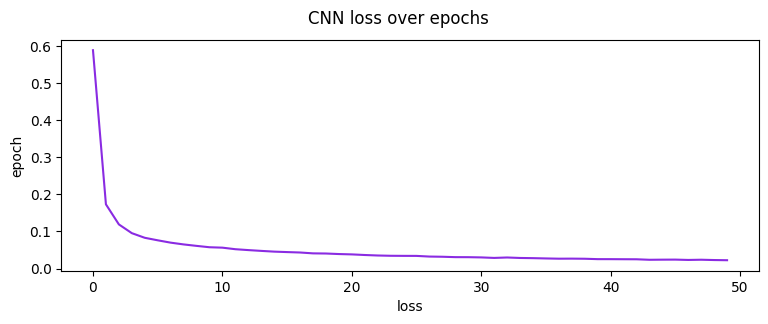

In [3]:
import numpy as np
import matplotlib.pyplot as plt

run_dat = np.load(r"C:\Dev\convolutional\conv_training\09_21_2026_11-22-10\run_data.npz", allow_pickle=True)
for item in run_dat:
    print(item)

# plot
fig, ax = plt.subplots()
fig.set_size_inches(9, 3)
ax.plot(np.arange(len(run_dat["loss"])), run_dat["loss"], c='blueviolet')
plt.xlabel('loss')
plt.ylabel('epoch')
plt.suptitle('CNN loss over epochs')

In [ ]:
#need to add sorting to these methods for when running on downloaded files/linux
def list_completed_LR_A_combos():
    from omegaconf import DictConfig, OmegaConf
    from pathlib import Path

    hyper_configs = []
    training_folder = Path("conv_training")
    for file_path in training_folder.rglob("*hyper_params.yaml"):

        tmp_cfg = OmegaConf.load(file_path)
        hyper_configs.append((tmp_cfg.learning_rate, tmp_cfg.leaky_ReLU_alpha))

    return hyper_configs

def find_min_loss():
    from omegaconf import DictConfig, OmegaConf
    from pathlib import Path
    import numpy as np

    ending_loss = []
    index = 0
    training_folder = Path("conv_training/09_21_2026_11-22-10")
    for file_path in training_folder.rglob("*run_data.npz"):
        with np.load(file_path, 'r') as run_data:
            loss = run_data['loss']

            ending_loss.append((round(loss[-1].item(), 4), round(np.min(loss[1:-1]).item(), 4)))

        index = index + 1

    return ending_loss

def get_loss():
    from omegaconf import DictConfig, OmegaConf
    from pathlib import Path
    import numpy as np

    loss = []
    index = 0
    training_folder = Path("conv_training/09_21_2026_11-22-10")
    for file_path in training_folder.rglob("*run_data.npz"):
        with np.load(file_path, 'r') as run_data:
            loss_sample = run_data['loss']

            loss.append(loss_sample)

        index = index + 1

    return loss

In [ ]:


hyper_prms = list_completed_LR_A_combos()
loss_list = find_min_loss()
index  = np.arange(len(hyper_prms))

All_losses = get_loss()

import matplotlib.pyplot as plt
x_vals= index
y_vals, z_vals = zip(*loss_list)
lr_vals, a_vals = zip(*hyper_prms)
plt.figure(figsize=(20, 10))
plt.yscale('log')   # Set y-axis to log scale

import matplotlib.cm as cm
number_o_lines = 4
cmap = cm.get_cmap('Purples', number_o_lines)
start, stop = 0.4, 1.0
colors = [cmap(start + (stop - start) * i / (number_o_lines - 1)) for i in range(number_o_lines)]
# Plot
plt.axhline(0.0000001,color='black', linewidth=1, linestyle='--')  # Customize color/style as needed#plt.xscale(2)   # Set x-axis to log scale
plt.scatter(x_vals, y_vals, marker='o', linestyle='-', label="final loss", color="dimgrey")  # or plt.scatter(x_vals, y_vals)
plt.scatter(x_vals, z_vals, marker='+', linestyle='-', label="min loss", color="blueviolet")  # or plt.scatter(x_vals, y_vals)
plt.scatter(x_vals, lr_vals, marker='x', linestyle='-', label="learning rate", color="r")  # or plt.scatter(x_vals, y_vals)
plt.scatter(x_vals, a_vals, marker='2', linestyle='-', label="alpha", color="k")  # or plt.scatter(x_vals, y_vals)
plt.yscale('log')   # Set y-axis to log scale
plt.title("Minimum and Final Loss over learning rates and alphas")
plt.xlabel("run_number")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.minorticks_on()
plt.grid(True, which='major', axis='x', linestyle='-', linewidth=0.75)
plt.grid(True, which='minor', axis='x', linestyle='--', linewidth=0.5, alpha=0.6)
plt.show()



In [ ]:
hyper_prms = list_completed_LR_A_combos()
loss_list = find_min_loss()
index  = np.arange(len(hyper_prms))

All_losses = get_loss()

import matplotlib.pyplot as plt
x_vals= np.arange(100)
y_vals, z_vals = zip(*loss_list)
plt.figure(figsize=(20, 10))
plt.yscale('log')   # Set y-axis to log scale


index2 = 1
for loss_lists in All_losses:
    #print(len(x_vals))
    #print(len(loss_lists))
    plt.plot(x_vals, loss_lists, marker='.', linestyle='-')
    if index2 % 20 == 0:
        plt.show()
        plt.figure(figsize=(20, 10))
        plt.yscale('log')   # Set y-axis to log scale

    index2 = 1 + index2


# Plot
#plt.scatter(x_vals, y_vals, marker='o', linestyle='-')  # or plt.scatter(x_vals, y_vals)
#plt.xscale(2)   # Set x-axis to log scale
plt.yscale('log')   # Set y-axis to log scale
plt.title("Plot of Points")
plt.xlabel("run_number")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


In [ ]:
from omegaconf import DictConfig, OmegaConf

mdl_cfg = OmegaConf.load("model.yaml")
lrn_cfg = OmegaConf.load("hyper_params.yaml")

lrn_cfg.leaky_ReLU_alpha
a_big_step = 10
a_sml_step = 2
a_num_b_steps = 6
alpha = 10

lr_big_step = 10
lr_sml_step = 2
lr_num_b_steps = 8
lr = 10


ending_loss = []
total_steps = a_num_b_steps * a_sml_step * lr_num_b_steps * lr_sml_step
print(f"total number of steps: {total_steps}")

hyper_configs = []
from pathlib import Path
training_folder = Path("conv_training")
for file_path in training_folder.rglob("*hyper_params.yaml"):

    tmp_cfg = OmegaConf.load(file_path)
    hyper_configs.append((tmp_cfg.learning_rate, tmp_cfg.leaky_ReLU_alpha))

print(hyper_configs)

for b_steps in range(1,lr_num_b_steps, 1):
    lr_pos = lr / ((lr_big_step)**b_steps)
    #print(a_pos)
    for steps in range(lr_sml_step-1, -1, -1):
#        print(steps)
        lr_sm_mult = ((1/lr_sml_step) *steps) + 1/lr_sml_step
        working_lr = lr_sm_mult * lr_pos
        #print("working_lr: ", working_lr)
        lrn_cfg.learning_rate = working_lr



        for b_steps in range(1,a_num_b_steps, 1):
            a_pos = alpha / ((a_big_step)**b_steps)
            for steps in range(a_sml_step-1, -1, -1):
                alpha_sm_mult = ((1/a_sml_step) *steps) + 1/a_sml_step
                working_a = alpha_sm_mult * a_pos


                prev_cmptd = list_completed_LR_A_combos()
                current_cmbo = (working_lr, working_a)
                print(f"currently testing {current_cmbo}")

                if current_cmbo in hyper_configs:
                    print(f"Already tested this setup({current_cmbo}), passing.")
                    continue  
                    

                #print("working_a: ", working_a)
                lrn_cfg.leaky_ReLU_alpha = working_a
                print(f"LR, A: {lrn_cfg.learning_rate}, {lrn_cfg.leaky_ReLU_alpha}")

                model = NN.create_network(mdl_cfg)
                trained_model, preformance, weights, loss_over_time_xy = train(lrn_cfg, mdl_cfg, model)

                print(preformance.save_dict_arrays["loss"][-1])
                ending_loss.append(preformance.save_dict_arrays["loss"][-1])
                preformance.save_to_file()
                weights.save_to_file(preformance.trn_cfg.date)







In [ ]:
import matplotlib.pyplot as plt

#evaluate on the 10k test images, which the network never trained on
test_images, test_labels = load_mnist("MNIST/t10k-images.idx3-ubyte", "MNIST/t10k-labels.idx1-ubyte")

choice = 13
plt.imshow(test_images[choice])
plt.show()
print("image key: ", test_labels[choice])

trained_model.forward(test_images[choice])
np.set_printoptions(precision=4, suppress=True)
print("network's guess: ", np.argmax(trained_model.blocks[-1].activations))
print(trained_model.blocks[-1].activations)
